## Load in packages and data

In [1]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import matplotlib.pyplot as plt
import matsim_output_analysis as moa
import operator

In [2]:
df = pd.read_csv(r"20000_sample.csv") #using look3, ignoring some fields such as carCO2
# df = pd.read_csv(r"2040baselineoutputs_231025.csv")
# df = pd.read_csv(r"NTI_20000_sample_routes.csv")
# df_spare = df #for resetting if needed

In [3]:
df = df[~df["subpopulation"].isin(["hgv","lgv","airport", "lgv_ev"])] #choose only the actual people

In [4]:
#turn plan summaries into lists instead of long strings
df['selected plan activity_type_or_mode'] = df['selected plan activity_type_or_mode'].str.split('; ')
df['selected plan distance_travelled'] = df['selected plan distance_travelled'].str.split('; ')
df['selected plan duration'] = df['selected plan duration'].str.split('; ')
df['selected plan location'] = df['selected plan location'].str.split('; ')
df['selected plan routes'] = df['selected plan routes'].str.split('; ')

df['unselected plan (1) activity_type_or_mode'] = df['unselected plan (1) activity_type_or_mode'].str.split('; ')
df['unselected plan (1) distance_travelled'] = df['unselected plan (1) distance_travelled'].str.split('; ')
df['unselected plan (1) duration'] = df['unselected plan (1) duration'].str.split('; ')
df['unselected plan (1) location'] = df['unselected plan (1) location'].str.split('; ')
df['unselected plan (1) routes'] = df['unselected plan (1) routes'].str.split('; ')

df['unselected plan (2) activity_type_or_mode'] = df['unselected plan (2) activity_type_or_mode'].str.split('; ')
df['unselected plan (2) distance_travelled'] = df['unselected plan (2) distance_travelled'].str.split('; ')
df['unselected plan (2) duration'] = df['unselected plan (2) duration'].str.split('; ')
df['unselected plan (2) location'] = df['unselected plan (2) location'].str.split('; ')
df['unselected plan (2) routes'] = df['unselected plan (2) routes'].str.split('; ')

df['unselected plan (3) activity_type_or_mode'] = df['unselected plan (3) activity_type_or_mode'].str.split('; ')
df['unselected plan (3) distance_travelled'] = df['unselected plan (3) distance_travelled'].str.split('; ')
df['unselected plan (3) duration'] = df['unselected plan (3) duration'].str.split('; ')
df['unselected plan (3) location'] = df['unselected plan (3) location'].str.split('; ')
df['unselected plan (3) routes'] = df['unselected plan (3) routes'].str.split('; ')

df['unselected plan (4) activity_type_or_mode'] = df['unselected plan (4) activity_type_or_mode'].str.split('; ')
df['unselected plan (4) distance_travelled'] = df['unselected plan (4) distance_travelled'].str.split('; ')
df['unselected plan (4) duration'] = df['unselected plan (4) duration'].str.split('; ')
df['unselected plan (4) location'] = df['unselected plan (4) location'].str.split('; ')
df['unselected plan (4) routes'] = df['unselected plan (4) routes'].str.split('; ')

## Remove "pt interaction" terms and all corresponding columns

In [5]:
#extract the indices of where pt interaction happens
df['selected plan ptinteraction_indices'] = df['selected plan activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (1) ptinteraction_indices'] = df['unselected plan (1) activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (2) ptinteraction_indices'] = df['unselected plan (2) activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (3) ptinteraction_indices'] = df['unselected plan (3) activity_type_or_mode'].apply(moa.get_ptinteraction_index)
df['unselected plan (4) ptinteraction_indices'] = df['unselected plan (4) activity_type_or_mode'].apply(moa.get_ptinteraction_index)

In [6]:
#remove the pt interaction activities
df['selected plan activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan activity_type_or_mode']), axis=1)
df['unselected plan (1) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) activity_type_or_mode']), axis=1)
df['unselected plan (2) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) activity_type_or_mode']), axis=1)
df['unselected plan (3) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) activity_type_or_mode']), axis=1)
df['unselected plan (4) activity_type_or_mode'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) activity_type_or_mode']), axis=1)

In [7]:
#remove the correspinding pt interaction durations
df['selected plan duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan duration']), axis=1)
df['unselected plan (1) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) duration']), axis=1)
df['unselected plan (2) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) duration']), axis=1)
df['unselected plan (3) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) duration']), axis=1)
df['unselected plan (4) duration'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) duration']), axis=1)

In [8]:
#remove the correspinding pt interaction locations
df['selected plan location'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan location']), axis=1)
df['unselected plan (1) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) location']), axis=1)
df['unselected plan (2) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) location']), axis=1)
df['unselected plan (3) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) location']), axis=1)
df['unselected plan (4) location'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) location']), axis=1)

In [9]:
#remove the correspinding pt interaction distance travelled
df['selected plan distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['selected plan ptinteraction_indices'], row['selected plan distance_travelled']), axis=1)
df['unselected plan (1) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (1) ptinteraction_indices'], row['unselected plan (1) distance_travelled']), axis=1)
df['unselected plan (2) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (2) ptinteraction_indices'], row['unselected plan (2) distance_travelled']), axis=1)
df['unselected plan (3) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (3) ptinteraction_indices'], row['unselected plan (3) distance_travelled']), axis=1)
df['unselected plan (4) distance_travelled'] = df.apply(lambda row: moa.remove_ptinteraction(row['unselected plan (4) ptinteraction_indices'], row['unselected plan (4) distance_travelled']), axis=1)

In [10]:
#clean  up table and remove indices
df = df.drop(["selected plan ptinteraction_indices","unselected plan (1) ptinteraction_indices","unselected plan (2) ptinteraction_indices","unselected plan (3) ptinteraction_indices","unselected plan (4) ptinteraction_indices"], axis=1)

## Extract the modes and the leg durations

In [11]:
#selected plan
#get activity indices
df["sp_activities_indices"] = df["selected plan activity_type_or_mode"].apply(moa.get_activities_indices_only)
#get stuck index out
df[["sp_activity_starts", "sp_activity_ends","sp_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["sp_activities_indices"], row["selected plan duration"], row["selected plan activity_type_or_mode"]), axis=1, result_type="expand")
#group times into trips
df["sp_trips_groups"] = df.apply(lambda row: moa.group_legs_into_trips(row["selected plan activity_type_or_mode"], row["sp_activities_indices"], row["sp_stuck_index"]), axis=1)
#group modes into trips
df["sp_trips_groups_duration"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["selected plan duration"], row["sp_activities_indices"], row["sp_stuck_index"], "duration"), axis=1)
df["sp_trips_groups_distance"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["selected plan distance_travelled"], row["sp_activities_indices"], row["sp_stuck_index"], "distance"), axis=1)

#get activity durations
df["sp_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["sp_activity_starts"], row["sp_activity_ends"], row["selected plan activity_type_or_mode"], row["sp_stuck_index"]), axis=1)

In [12]:
df = df.drop(["sp_activities_indices", "sp_activity_starts", "sp_activity_ends","sp_stuck_index"], axis=1)

In [13]:
#unselected plan 1
#get activity indices
df["up1_activities_indices"] = df["unselected plan (1) activity_type_or_mode"].apply(moa.get_activities_indices_only)
#get stuck index out
df[["up1_activity_starts", "up1_activity_ends","up1_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up1_activities_indices"], row["unselected plan (1) duration"], row["unselected plan (1) activity_type_or_mode"]), axis=1, result_type="expand")
#group times into trips
df["up1_trips_groups"] = df.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (1) activity_type_or_mode"], row["up1_activities_indices"], row["up1_stuck_index"]), axis=1)
#group modes into trips
df["up1_trips_groups_duration"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (1) duration"], row["up1_activities_indices"], row["up1_stuck_index"], "duration"), axis=1)
df["up1_trips_groups_distance"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (1) distance_travelled"], row["up1_activities_indices"], row["up1_stuck_index"], "distance"), axis=1)
#get activity durations
df["up1_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up1_activity_starts"], row["up1_activity_ends"], row["selected plan activity_type_or_mode"], row["up1_stuck_index"]), axis=1)

In [14]:
df = df.drop(["up1_activities_indices", "up1_activity_starts", "up1_activity_ends","up1_stuck_index"], axis=1)

In [15]:
#unselected plan 2
#get activity indices
df["up2_activities_indices"] = df["unselected plan (2) activity_type_or_mode"].apply(moa.get_activities_indices_only)
#get stuck index out
df[["up2_activity_starts", "up2_activity_ends","up2_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up2_activities_indices"], row["unselected plan (2) duration"], row["unselected plan (2) activity_type_or_mode"]), axis=1, result_type="expand")
#group times into trips
df["up2_trips_groups"] = df.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (2) activity_type_or_mode"], row["up2_activities_indices"], row["up2_stuck_index"]), axis=1)
#group modes into trips
df["up2_trips_groups_duration"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (2) duration"], row["up2_activities_indices"], row["up2_stuck_index"], "duration"), axis=1)
df["up2_trips_groups_distance"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (2) distance_travelled"], row["up2_activities_indices"], row["up2_stuck_index"], "distance"), axis=1)

#get activity durations
df["up2_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up2_activity_starts"], row["up2_activity_ends"], row["selected plan activity_type_or_mode"], row["up2_stuck_index"]), axis=1)

In [16]:
df = df.drop(["up2_activities_indices", "up2_activity_starts", "up2_activity_ends","up2_stuck_index"], axis=1)

In [17]:
#unselected plan 3
#get activity indices
df["up3_activities_indices"] = df["unselected plan (3) activity_type_or_mode"].apply(moa.get_activities_indices_only)
#get stuck index out
df[["up3_activity_starts", "up3_activity_ends","up3_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up3_activities_indices"], row["unselected plan (3) duration"], row["unselected plan (3) activity_type_or_mode"]), axis=1, result_type="expand")
#group times into trips
df["up3_trips_groups"] = df.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (3) activity_type_or_mode"], row["up3_activities_indices"], row["up3_stuck_index"]), axis=1)
#group modes into trips
df["up3_trips_groups_duration"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (3) duration"], row["up3_activities_indices"], row["up3_stuck_index"], "duration"), axis=1)
df["up3_trips_groups_distance"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (3) distance_travelled"], row["up3_activities_indices"], row["up3_stuck_index"], "distance"), axis=1)

#get activity durations
df["up3_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up3_activity_starts"], row["up3_activity_ends"], row["selected plan activity_type_or_mode"], row["up3_stuck_index"]), axis=1)

In [18]:
df = df.drop(["up3_activities_indices", "up3_activity_starts", "up3_activity_ends","up3_stuck_index"], axis=1)

In [19]:
#unselected plan 4
#get activity indices
df["up4_activities_indices"] = df["unselected plan (4) activity_type_or_mode"].apply(moa.get_activities_indices_only)
#get stuck index out
df[["up4_activity_starts", "up4_activity_ends","up4_stuck_index"]] = df.apply(lambda row: moa.get_activity_timings(row["up4_activities_indices"], row["unselected plan (4) duration"], row["unselected plan (4) activity_type_or_mode"]), axis=1, result_type="expand")
#group times into trips
df["up4_trips_groups"] = df.apply(lambda row: moa.group_legs_into_trips(row["unselected plan (4) activity_type_or_mode"], row["up4_activities_indices"], row["up4_stuck_index"]), axis=1)
#group modes into trips
df["up4_trips_groups_duration"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (4) duration"], row["up4_activities_indices"], row["up4_stuck_index"], "duration"), axis=1)
df["up4_trips_groups_distance"] = df.apply(lambda row: moa.group_legs_into_trips_d(row["unselected plan (4) distance_travelled"], row["up4_activities_indices"], row["up4_stuck_index"], "distance"), axis=1)

#get activity durations
df["up4_activity_durations"] = df.apply(lambda row: moa.get_activity_durations(row["up4_activity_starts"], row["up4_activity_ends"], row["selected plan activity_type_or_mode"], row["up4_stuck_index"]), axis=1)

In [20]:
df = df.drop(["up4_activities_indices", "up4_activity_starts", "up4_activity_ends","up4_stuck_index"], axis=1)

In [21]:
df["trips_modes"] = df[["sp_trips_groups", "up1_trips_groups", "up2_trips_groups", "up3_trips_groups","up4_trips_groups"]].apply(lambda row: list(row), axis=1)
df["trips_durations"] = df[["sp_trips_groups_duration", "up1_trips_groups_duration", "up2_trips_groups_duration", "up3_trips_groups_duration","up4_trips_groups_duration"]].apply(lambda row: list(row), axis=1)
df["trips_distance"] = df[["sp_trips_groups_distance", "up1_trips_groups_distance", "up2_trips_groups_distance", "up3_trips_groups_distance","up4_trips_groups_distance"]].apply(lambda row: list(row), axis=1)
df["all_utilities"] = df[["selected plan utility", "unselected plan (1) utility", "unselected plan (2) utility", "unselected plan (3) utility","unselected plan (4) utility"]].apply(lambda row: list(row), axis=1)
df["all_activity_durations"] = df[["sp_activity_durations", "up1_activity_durations", "up2_activity_durations", "up3_activity_durations","up4_activity_durations"]].apply(lambda row: list(row), axis=1)

In [22]:
def assignLongestLeg(trips, distances, id):
    mainMode = []
    # print(trips)
    # print(distances)
    for i in range(len(trips)):
        try:
            # print(distances[i][0])
            maxval = max(distances[i][0])
            temp = trips[i][0][distances[i][0].index(maxval)]
            # print(temp)
            mainMode.append(temp)
        except: #this fails when there are stuck agents - WHY THOUGH??
            # because in at least one plan they dont even make their first trip
            # print(f"id: {id}")
            mainMode.append("Stuck")

    return mainMode


In [23]:
df["trips_main_mode"] = df.apply(lambda row: assignLongestLeg(row["trips_modes"], row["trips_distance"], row["id"]),axis=1)
#use this OR "first_trip_modes"

In [24]:
def summariseAdjacentLegs(trips):
    final_new_trips = []
    # print(trips)
    for sublist_i in trips: 
        sub_new_trips = []
        for sublist_j in sublist_i:
            temp = [
                item for i, item in enumerate(sublist_j) 
                if i == 0 or item != sublist_j[i - 1]
            ]
            # print(temp)
            sub_new_trips.append(temp)
        final_new_trips.append(sub_new_trips)
    return(final_new_trips)

In [26]:
df["trips_modes_summarised"] = df["trips_modes"].apply(summariseAdjacentLegs)

In [27]:
df.iloc[2]["trips_modes"]


[[['bike', 'walk', 'bus', 'walk'], ['walk', 'walk', 'bus', 'walk', 'walk']],
 [['taxi', 'walk', 'walk', 'bus', 'walk'],
  ['walk', 'walk', 'bus', 'walk', 'walk']],
 [['walk', 'bus', 'walk', 'bus', 'walk'],
  ['walk', 'walk', 'bus', 'walk', 'bike']],
 [['walk', 'bus', 'walk', 'bus', 'walk'],
  ['walk', 'walk', 'bus', 'walk', 'walk', 'taxi']],
 [['taxi', 'walk', 'walk', 'bus', 'walk'],
  ['walk', 'walk', 'bus', 'walk', 'walk']]]

In [28]:
df.iloc[2]["trips_modes_summarised"]

[[['bike', 'walk', 'bus', 'walk'], ['walk', 'bus', 'walk']],
 [['taxi', 'walk', 'bus', 'walk'], ['walk', 'bus', 'walk']],
 [['walk', 'bus', 'walk', 'bus', 'walk'], ['walk', 'bus', 'walk', 'bike']],
 [['walk', 'bus', 'walk', 'bus', 'walk'], ['walk', 'bus', 'walk', 'taxi']],
 [['taxi', 'walk', 'bus', 'walk'], ['walk', 'bus', 'walk']]]

## Start by just looking at the first trip before figuring out how to do dynamic across all trips (need it so that more trips doesnt necessarily mean more flexibility)

Using selected plan as the anchor

In [ ]:
#turn the first modes and first durations, and overall utilities into their own columns
df["first_trip_modes_sum"] = df["trips_modes_summarised"].apply(lambda x: [inner[0] if isinstance(inner, list) and inner else None for inner in x] if isinstance(x, list) else None)
df["first_trip_modes"] = df["trips_modes"].apply(lambda x: [inner[0] if isinstance(inner, list) and inner else None for inner in x] if isinstance(x, list) else None)
df["first_trip_durations"] = df["trips_durations"].apply(lambda x: [inner[0] if isinstance(inner, list) and inner else None for inner in x] if isinstance(x, list) else None)

df["first_activity_durations"] = df["all_activity_durations"].apply(
    lambda x: [
            inner[1] if isinstance(inner, list) and len(inner) > 1 else 1 
                    for inner in x
                        ] if isinstance(x, list) else None
                        )

In [30]:
#so this function just looks at the highest scoring unique modes, agnostic of which the selected plan is
#but i think we need something to be an anchor since this whole thing is relative and comparative
def trips_to_keep(modes, durations, utilities):
    if not modes:
        return [], [], []
    if not (len(modes) == len(durations) == len(utilities)):
        raise ValueError("All three lists must have the same length")

    def dur_value(d):
        # if d is a list/tuple -> sum it; if None -> 0; else return scalar as-is
        if d is None:
            return 0
        if isinstance(d, (list, tuple)):
            return sum(d)
        return d

    # handle single-element case
    if len(modes) == 1:
        return (
            [tuple(modes[0]) if isinstance(modes[0], list) else modes[0]],
            [dur_value(durations[0])],
            [utilities[0]]
        )

    modes_fixed = [tuple(m) if isinstance(m, list) else m for m in modes]
    first_key = modes_fixed[0]
    # best per key -> (value, index)
    best = {}

    # scan items after index 0
    for idx in range(1, len(modes_fixed)):
        k = modes_fixed[idx]
        if k == first_key:
            continue
        v = dur_value(durations[idx])
        if k not in best or v > best[k][0] or (v == best[k][0] and idx < best[k][1]):
            best[k] = (v, idx)

    # preserve order by the chosen item index (stable order)
    chosen_indices = [best[k][1] for k in sorted(best, key=lambda kk: best[kk][1])]

    # build output lists: prepend index 0
    out_keys   = [modes_fixed[0]] + [modes_fixed[i] for i in chosen_indices]
    out_values = [dur_value(durations[0])] + [dur_value(durations[i]) for i in chosen_indices]
    out_extras = [utilities[0]] + [utilities[i] for i in chosen_indices]

    return out_keys, out_values, out_extras


In [31]:
def calculate_flex_score_1(modes, durations, utilities, id):
    components = []
    # print(f"modes: {modes}")
    # print(f"durations: {durations}")
    # print(f"us: {utilities}")
    # print(f"id: {id}")
    k = 2.2
    j = 9 #these need setting more determinately
    for i in range(1, len(modes)):
        utility_ratio = (utilities[0]-utilities[i])/utilities[0]
        # print(f"utility ratio:{utility_ratio}")
        if durations[0] == 0:
            durations[0] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        if durations[i] == 0:
            durations[i] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        duration_ratio = (durations[0]-durations[i])/durations[0]
        # print(f"duration ratio:{duration_ratio}")
        if utility_ratio >= 0:
            temp = (1/(1+np.exp(-k*duration_ratio))) * (1 - np.tanh(utility_ratio/j))
        else:
            temp = ((1/(1+np.exp(-k*duration_ratio))) * (1 + np.tanh(utility_ratio/j))) - np.tanh(utility_ratio/j)
        components.append(temp)
    # print(components)
    return(np.mean(components))

In [32]:
def calculate_flex_score_2(modes, durations, utilities):
    components = []
    k = 2.2
    for i in range(1, len(modes)):

        utility_ratio = (utilities[0]-utilities[i])/utilities[0]
        if durations[0] == 0:
            durations[0] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        if durations[i] == 0:
            durations[i] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        # print(f"utility ratio:{utility_ratio}")
        duration_ratio = (durations[0]-durations[i])/durations[0]
        # print(f"DR: {duration_ratio}")
        # print(f"ID: {id}")
        # print(f"duration ratio:{duration_ratio}")
        temp = (1/(1+np.exp((-k*duration_ratio)+utility_ratio))) 
        # print(temp)
        components.append(temp)

    # print(components)
    return(np.mean(components))

In [33]:
def calculate_flex_score_3_unadjusted(modes, durations, utilities):
    components = [0,0,0,0] #maxium of 5 different modes giving 4 different flexes (can vary) 
    k = 2.94
    beta = 0.29
    for i in range(1, len(modes)):
        # utility_ratio = (utilities[0]-utilities[i])/utilities[0]
        if durations[0] == 0:
            durations[0] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        if durations[i] == 0:
            durations[i] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        # print(f"utility ratio:{utility_ratio}")
        duration_ratio = (durations[0]-durations[i])/durations[0]
        temp = (2/(1+np.exp(k*abs(duration_ratio)))) 
        # components.append(temp)
        components[i-1]= (temp)
    return(np.sum(components))

In [34]:
def calculate_flex_score_3(modes, durations, utilities):
    components = [0,0,0,0] #maxium of 5 different modes giving 4 different flexes (can vary) 
    k = 2.94
    beta = 0.29
    for i in range(1, len(modes)):
        try:
            utility_ratio = (utilities[0]-utilities[i])/utilities[0]
        except ZeroDivisionError:
            utility_ratio = 0
        if durations[0] == 0:
            durations[0] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        if durations[i] == 0:
            durations[i] = 1 #TODO: set it to 1 second for zero duration travel - are we sure????
        # print(f"utility ratio:{utility_ratio}")
        duration_ratio = (durations[0]-durations[i])/durations[0]
        if duration_ratio * utility_ratio >= 0: #these need swapping when i switch to utilities
            sigma = -1
        else:
            sigma = 1
        temp = (2/(1+np.exp(k*abs(duration_ratio)*np.exp(sigma*beta*abs(utility_ratio))))) 
        # components.append(temp)
        components[i-1]= (temp)
    # components_sort = sorted(components, reverse=True)
    # print((components_sort))
    # print(components)
    # print(components_sort[0:3])
    # return(np.mean(components_sort[0:2]))
    return(np.sum(components))

In [35]:
df[["m_sum", "d_sum", "u_sum"]] = df.apply(lambda row: trips_to_keep(row["first_trip_modes_sum"], row["first_trip_durations"], row["first_activity_durations"]), axis=1, result_type="expand")
df[["m_main", "d_main", "u_main"]] = df.apply(lambda row: trips_to_keep(row["trips_main_mode"], row["first_trip_durations"], row["first_activity_durations"]), axis=1, result_type="expand")
df[["m", "d", "u"]] = df.apply(lambda row: trips_to_keep(row["first_trip_modes"], row["first_trip_durations"], row["first_activity_durations"]), axis=1, result_type="expand")

In [36]:
# a = df.loc[df['id'] == 200924, 'm'].item()
# b = df.loc[df['id'] == 200924, 'd'].item()
# c = df.loc[df['id'] == 200924, 'u'].item()

In [37]:
# calculate_flex_score_3_unadjusted(a,b,c)

### running these functions!

In [38]:
# import warnings

# def safe_trips_to_keep_warn(row):
#     with warnings.catch_warnings(record=True) as w:
#         warnings.simplefilter("always")  # capture all warnings

#         result = calculate_flex_score_2(
#             row["m"],
#             row["d"],
#             row["u"]
#         )

#         # inspect recorded warnings
#         for warning in w:
#             msg = str(warning.message)
#             if "overflow encountered in exp" in msg or "overflow encountered" in msg:
#                 print("Overflow RuntimeWarning in row:", row.name)
#                 print("Warning message:", msg)
#                 print("Inputs:", {
#                     "m": row.get("m"),
#                     "d": row.get("d"),
#                     "u": row.get("u")
#                 })
#                 # optionally break or continue logging others

#         return result

In [39]:
# df["test"] = df.apply(safe_trips_to_keep_warn, axis=1, result_type="expand")

In [40]:
# df["flex_option_1"] = df.apply(lambda row: calculate_flex_score_1(row["m"], row["d"], row["u"], row["id"]), axis=1)
# df["flex_option_2"] = df.apply(lambda row: calculate_flex_score_2(row["m"], row["d"], row["u"]), axis=1)
df["flex_option_3"] = df.apply(lambda row: calculate_flex_score_3(row["m"], row["d"], row["u"]), axis=1)
df["flex_option_3_sum"] = df.apply(lambda row: calculate_flex_score_3(row["m_sum"], row["d_sum"], row["u_sum"]), axis=1)
df["flex_option_3_main"] = df.apply(lambda row: calculate_flex_score_3(row["m_main"], row["d_main"], row["u_main"]), axis=1)
df["flex_option_3_unadjusted"] = df.apply(lambda row: calculate_flex_score_3_unadjusted(row["m"], row["d"], row["u"]), axis=1)
df["flex_option_3_unadjusted_sum"] = df.apply(lambda row: calculate_flex_score_3_unadjusted(row["m_sum"], row["d_sum"], row["u_sum"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3890739956.py:20: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(duration_ratio)*np.exp(sigma*beta*abs(utility_ratio)))))
C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3890739956.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  utility_ratio = (utilities[0]-utilities[i])/utilities[0]
C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3890739956.py:16: RuntimeWarning: invalid value encountered in scalar multiply
  if duration_ratio * utility_ratio >= 0: #these need swapping when i switch to utilities
C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3890739956.py:20: RuntimeWarning: invalid value encountered in scalar multiply
  temp = (2/(1+np.exp(k*abs(duration_ratio)*np.exp(sigma*beta*abs(utility_ratio)))))
C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3890739956.py:20: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(duration_ratio)*np.exp(sigma*beta*abs(utilit

### Plot distributions

In [41]:
# df1 = df[df["flex_option_1"]>1E-4]
# df2 = df[df["flex_option_2"]>1E-4]
df3 = df[df["flex_option_3_sum"]>0]
df3_unadjusted = df[df["flex_option_3_unadjusted_sum"]>0]
print(len(df3))
# df3 = df3[~df3["d"].apply(lambda x: all(v == 1 for v in x))]
# print(len(df3))

2218


Text(0, 0.5, 'flex score (F)')

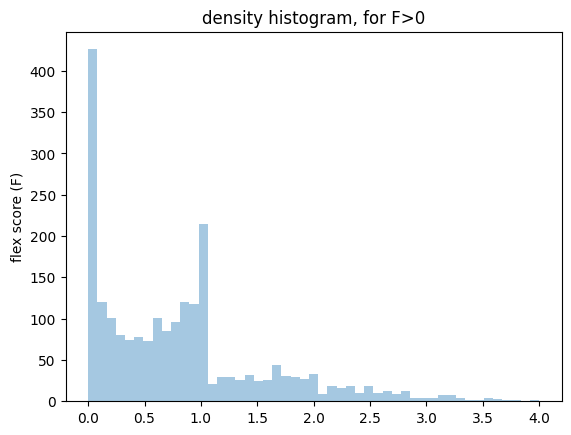

In [42]:
# plt.hist(df1["flex_option_1"], bins=150, alpha=0.4, label = "option 1")
# plt.hist(df2["flex_option_2"], bins = 150, alpha=0.4, label = "option 2")
# plt.hist(df3["flex_option_3"], bins = np.linspace(0,4,50), alpha=0.4, label = "all modes")
plt.hist(df3["flex_option_3_sum"], bins =  np.linspace(0,4,50), alpha=0.4)
# plt.hist(df3["flex_option_3_main"], bins =  np.linspace(0,4,50), alpha=0.4, label = "main mode")
# plt.hist(df3_unadjusted["flex_option_3_unadjusted"], bins = 50, alpha=0.4, label = "unadjusted")
# plt.hist(df3[df3["hhincome"]=="high"]["flex_option_3"], bins = 10, alpha=0.4, label = "high", density=True)
# plt.hist(df3[df3["hhincome"]=="medium"]["flex_option_3"], bins = 10, alpha=0.4, label = "med", density=True)
# plt.hist(df3[df3["hhincome"]=="low"]["flex_option_3"], bins = 10, alpha=0.4, label = "low", density=True)
# plt.hist(df3[df3["subpopulation"]=="ev_high"]["flex_option_3"], bins = 50, alpha=0.4, label = "ev_high", density=True)
# plt.hist(df3[df3["subpopulation"]=="ev_low"]["flex_option_3"], bins = 50, alpha=0.4, label = "ev_low", density=True)
# plt.hist(df3[df3["subpopulation"]=="ev_medium"]["flex_option_3"], bins = 50, alpha=0.4, label = "ev_med", density=True)
# plt.hist(df3[df3["area_type"]=="rural"]["flex_option_3"], bins = 50, alpha=0.4, label = "rural", density=True)
# plt.hist(df3[df3["area_type"]=="urban"]["flex_option_3"], bins = 50, alpha=0.4, label = "urban", density=True)
# plt.legend(title = "mode granularity")
plt.title("density histogram, for F>0")
plt.ylabel("flex score (F)")
# plt.ylim(0,70)

Text(0.5, 1.0, 'Effect of applying adjustment for activity duration')

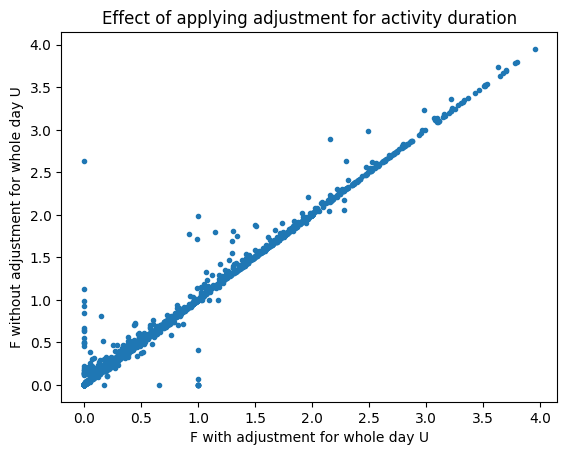

In [43]:
plt.plot(df["flex_option_3_sum"], df["flex_option_3_unadjusted_sum"],'.')
plt.xlabel("F with adjustment for whole day U")
plt.ylabel("F without adjustment for whole day U")
plt.title("Effect of applying adjustment for activity duration")

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00, 3.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 4.0000e+00, 2.0000e+00,
        0.0000e+00, 2.0000e+00, 3.0000e+00, 2.0000e+00, 0.0000e+00,
        7.0000e+00, 6.0000e+00, 9.0000e+00, 2.8000e+01, 3.4000e+01,
        7.1000e+01, 2.6600e+02, 1.7864e+04, 3.90

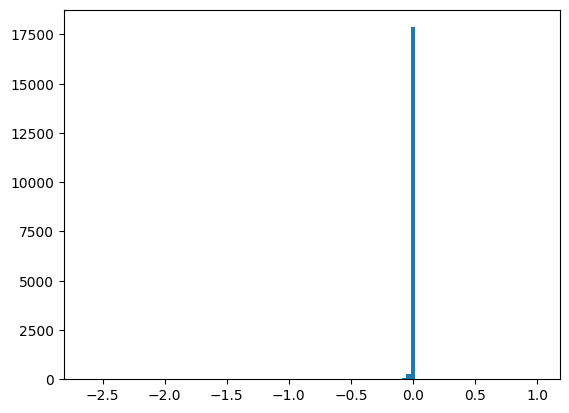

In [44]:
df["flex_diff"] = (df["flex_option_3_sum"]-df["flex_option_3_unadjusted_sum"])
plt.hist(df["flex_diff"], bins=100)

In [159]:
df.loc[11012]["selected plan activity_type_or_mode"]

['business',
 'walk',
 'bus',
 'walk',
 'rail',
 'walk',
 'rail',
 'walk',
 'bus',
 'walk',
 'bus',
 'walk',
 'business',
 'taxi',
 'walk',
 'rail',
 'walk',
 'bus',
 'walk',
 'rail',
 'walk',
 'car',
 'home',
 'walk',
 'bus',
 'walk',
 'bus',
 'walk',
 'rail',
 'walk',
 'rail',
 'walk',
 'car',
 'escort_other',
 'car',
 'walk',
 'rail',
 'walk',
 'rail',
 'walk',
 'rail',
 'walk',
 'rail',
 'walk',
 'taxi',
 'home',
 'car',
 'escort_work',
 'car',
 'home',
 'car',
 'other',
 'car',
 'home']

In [158]:
df.loc[11012]["selected plan duration"]

['08:08:39',
 '00:03:39',
 '00:30:42',
 '00:00:46',
 '00:43:09',
 '00:00:00',
 '00:55:59',
 '00:00:32',
 '00:04:06',
 '00:08:06',
 '00:33:13',
 '00:02:14',
 '11:09:22',
 '00:05:06',
 '00:00:00',
 '01:40:32',
 '00:03:03',
 '00:41:52',
 '00:04:18',
 '00:27:37',
 '00:00:00',
 '00:08:10',
 '14:07:53',
 '00:11:48',
 '00:21:19',
 '00:03:09',
 '01:15:46',
 '00:03:03',
 '00:32:52',
 '00:00:00',
 '00:23:59',
 '00:00:00',
 '00:06:44',
 '14:32:22',
 '00:03:53',
 '00:00:00',
 '00:44:45',
 '00:00:00',
 '00:16:59',
 '00:00:00',
 '00:37:59',
 '00:12:48',
 '00:06:07',
 '00:00:00',
 '00:08:43',
 '17:08:13',
 '01:32:47',
 '17:05:41',
 '01:49:57',
 '20:29:16',
 '01:08:58',
 '21:34:38',
 '01:30:29',
 '24:09:26']

In [435]:
df3.groupby("hhincome")["flex_option_3"].quantile(q=0.75)

hhincome
high      1.547701
low       1.000000
medium    1.000000
Name: flex_option_3, dtype: float64

In [45]:
def aggregateAges(age_group):
    if age_group in ["0 to 4", "5 to 10", "11 to 15"]:
        return ("15 and under")
    elif age_group in ["16 to 20", "21 to 25"]:
        return ("16 to 25")
    elif age_group in ["26 to 29", "30 to 39"]:
        return ("26 to 39")
    elif age_group in ["40 to 49", "50 to 59", "60 to 64"]:
        return("40 to 65")
    elif age_group in ["65 to 69", "70 to 74", "75 to 79", "80 to 84", "85  and over"]:
        return("65 and over")
    else:
        return("none")
df3["aggregate_age"]=df3["age_group"].apply(aggregateAges)

C:\Users\maria\AppData\Local\Temp\ipykernel_40956\2643688622.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["aggregate_age"]=df3["age_group"].apply(aggregateAges)


In [378]:
# a = list(df3[df3["age_group"]=="0 to 4"]["flex_option_3"])
# b = list(df3[df3["age_group"]=="5 to 10"]["flex_option_3"])
# c = list(df3[df3["age_group"]=="11 to 15"]["flex_option_3"])
# d = list(df3[df3["age_group"]=="16 to 20"]["flex_option_3"])
# e = list(df3[df3["age_group"]=="21 to 25"]["flex_option_3"])
# f = list(df3[df3["age_group"]=="26 to 29"]["flex_option_3"])
# g = list(df3[df3["age_group"]=="30 to 39"]["flex_option_3"])
# h = list(df3[df3["age_group"]=="40 to 49"]["flex_option_3"])
# i = list(df3[df3["age_group"]=="50 to 59"]["flex_option_3"])
# j = list(df3[df3["age_group"]=="60 to 64"]["flex_option_3"])
# k = list(df3[df3["age_group"]=="65 to 69"]["flex_option_3"])
# l = list(df3[df3["age_group"]=="70 to 74"]["flex_option_3"])
# m = list(df3[df3["age_group"]=="75 to 79"]["flex_option_3"])
# n = list(df3[df3["age_group"]=="80 to 84"]["flex_option_3"])
# o = list(df3[df3["age_group"]=="85  and over"]["flex_option_3"])


a = list(df3[df3["aggregate_age"]=="15 and under"]["flex_option_3"])
b = list(df3[df3["aggregate_age"]=="16 to 25"]["flex_option_3"])
c = list(df3[df3["aggregate_age"]=="26 to 39"]["flex_option_3"])
d = list(df3[df3["aggregate_age"]=="40 to 65"]["flex_option_3"])
e = list(df3[df3["aggregate_age"]=="65 and over"]["flex_option_3"])


In [438]:
a = list(df3[df3["occupation"]=="unskilled"]["flex_option_3"])
b = list(df3[df3["occupation"]=="partly_skilled"]["flex_option_3"])
c = list(df3[df3["occupation"]=="skilled_manual"]["flex_option_3"])
d = list(df3[df3["occupation"]=="skilled_non_manual"]["flex_option_3"])
e = list(df3[df3["occupation"]=="professional"]["flex_option_3"])
f = list(df3[df3["occupation"]=="managerial"]["flex_option_3"])
g = list(df3[df3["occupation"]=="na_freight"]["flex_option_3"])


In [439]:
# a = list(df3[df3["gender"]=="female"]["flex_option_3"])
# b = list(df3[df3["gender"]=="male"]["flex_option_3"])
#
# a = list(df3[df3["disabled"]=="yes"]["flex_option_3"])
# b = list(df3[df3["disabled"]=="no"]["flex_option_3"])

a = list(df3[df3["seasontickettype"]=="no"]["flex_option_3"])
b = list(df3[df3["seasontickettype"]=="old_pass"]["flex_option_3"])
c = list(df3[df3["seasontickettype"]=="season_ticket"]["flex_option_3"])
d = list(df3[df3["seasontickettype"]=="other"]["flex_option_3"])

In [466]:
# a = list(df3[df3["hhincome"]=="high"]["flex_option_3"])
# b = list(df3[df3["hhincome"]=="medium"]["flex_option_3"])
# c = list(df3[df3["hhincome"]=="low"]["flex_option_3"])

# a = list(df3[df3["area_type"]=="rural"]["flex_option_3"])
# b = list(df3[df3["area_type"]=="urban"]["flex_option_3"])

# a = list(df3[df3["region"]=="London"]["flex_option_3"])
# b = list(df3[df3["region"]=="East of England"]["flex_option_3"])

a = list(df3[df3["subpopulation"]=="high"]["flex_option_3"])
b = list(df3[df3["subpopulation"]=="medium"]["flex_option_3"])
c = list(df3[df3["subpopulation"]=="low"]["flex_option_3"])
d = list(df3[df3["subpopulation"]=="ev_high"]["flex_option_3"])
e = list(df3[df3["subpopulation"]=="ev_medium"]["flex_option_3"])
f = list(df3[df3["subpopulation"]=="ev_low"]["flex_option_3"])

C:\Users\maria\AppData\Local\Temp\ipykernel_43092\992503393.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bp.set_xticklabels(#["car","no car"],


Text(0, 0.5, 'Flex score (F) excluding zeros')

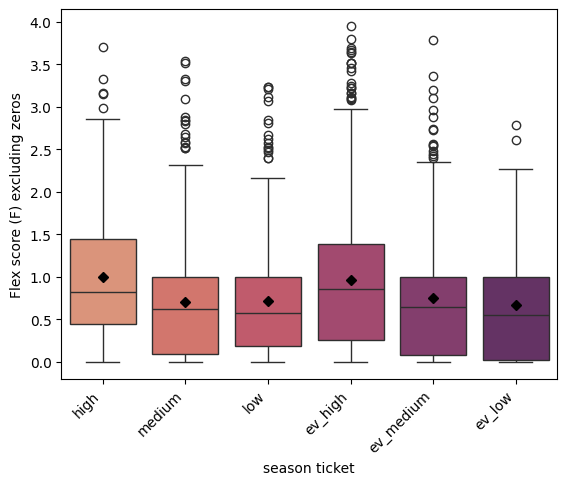

In [467]:
import seaborn as sns
mean_properties = {
    'marker': 'D',          # Marker shape (e.g., 'o', 's', 'D', '*')
    'markersize': 5,       # Size of the marker
    'markerfacecolor': 'black', # The color of the marker's face
    'markeredgecolor': 'black', # The color of the marker's edge
    'markeredgewidth': 1    # Width of the marker's edge
}
bp = sns.boxplot(
    data = [a,b,c,d,e,f],#g],#,h,i,j,k,l,m,n,o],
    palette="flare",
    showmeans=True,
    meanprops=mean_properties)
bp.set_xticklabels(#["car","no car"],
                #["no", "old_pass","season ticket","other"],
                #["London","EOE"],
                #["urban","rural"],
                ["high","medium", "low", "ev_high","ev_medium", "ev_low"],
                #["0-4","5-10","11-15","16-20","21-25", "26-29","30-39","40-49","50-59","60-64","65-69","70-74","75-79","80-84","85+"],
                #["15 and under", "16 to 25", "26 to 39", "40 to 65","65 and over"],
                #["unskilled","partly skilled", "skilled manual", "skilled non manual", "professional","managerial","na freight"],
                rotation=45,  # Rotate the labels by 45 degrees
                ha="right")
bp.set_xlabel("season ticket")

bp.set_ylabel("Flex score (F) excluding zeros")

### Mappings

In [212]:
def get_home_index(item_list):
    index = [i for i, val in enumerate(item_list) if val == 'home']
    return index if index else [0] # get the index of where home is if there is a home. if no home, return index 0 (first location)
def get_home_coords(values, indices):
    if not indices:
        return pd.NA
    if not isinstance(values, list) or not isinstance(indices, list):
        raise TypeError("Both values and indices should be lists")

    first_index = indices[0]
    if 0 <= first_index < len(values):
        return values[first_index]
    else:
        return pd.NA

In [213]:
df["home_index"] = df['selected plan activity_type_or_mode'].apply(get_home_index)
df["home_coords"] = df.apply(lambda row: get_home_coords(row['selected plan location'], row['home_index']), axis=1)
df[['home_x', 'home_y']] = df['home_coords'].str.split(',', expand=True).astype(float)

In [214]:
import geopandas as gpd
from shapely.geometry import Point
def parse_coords(coord_str):
    try:
        if not isinstance(coord_str, str) or ',' not in coord_str:
            return None
        x_str, y_str = coord_str.split(',')
        x, y = float(x_str.strip()), float(y_str.strip())
        return Point(x, y)
    except:
        return None
df['geometry'] = df['home_coords'].apply(parse_coords)
df = df[df['geometry'].notnull()].copy()
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:27700")  

In [241]:
from shapely.geometry import box
grid_size = 10000  # adjust this to your desired grid cell size

# Get total bounds of your points: (xmin, ymin, xmax, ymax)
xmin, ymin, xmax, ymax = gdf.total_bounds

# Create the grid cells
x_coords = np.arange(xmin, xmax + grid_size, grid_size)
y_coords = np.arange(ymin, ymax + grid_size, grid_size)

grid_cells = []
for x0 in x_coords[:-1]:
    for y0 in y_coords[:-1]:
        x1 = x0 + grid_size
        y1 = y0 + grid_size
        grid_cells.append(box(x0, y0, x1, y1))

grid = gpd.GeoDataFrame({'geometry': grid_cells})
grid.set_crs(gdf.crs, inplace=True)
joined = gpd.sjoin(gdf, grid, how='inner', predicate='within')
grid['mean_f'] = joined.groupby('index_right')['flex_option_3'].mean() # should it be mean or median?
grid['median_f'] = joined.groupby('index_right')['flex_option_3'].median() # should it be mean or median?

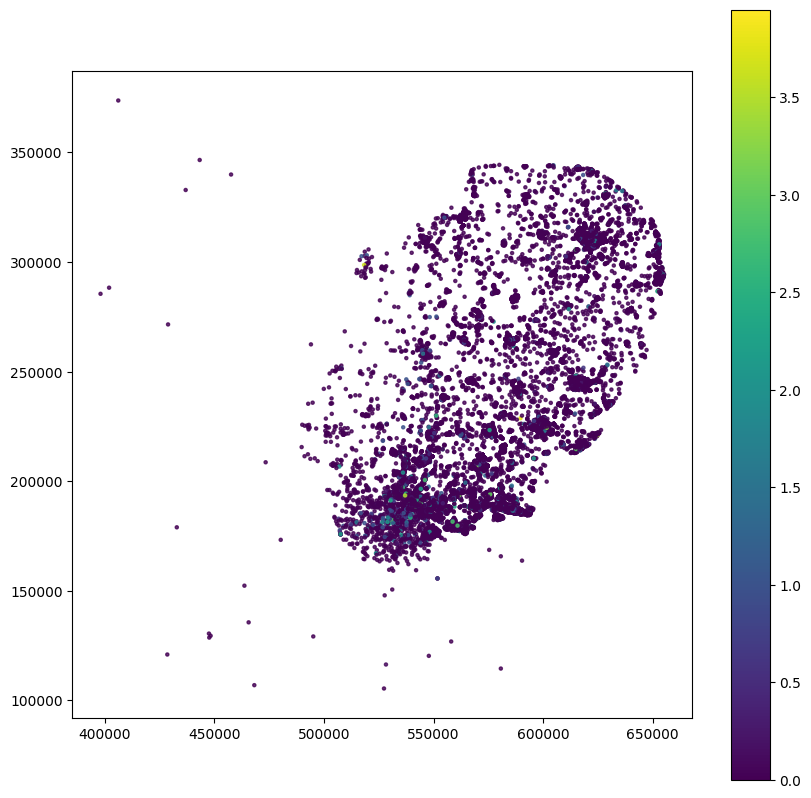

In [222]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column='flex_option_3',
    cmap='viridis',
    legend=True,
    markersize=5,
    alpha=0.8,
    marker = 'o'
)

plt.show()

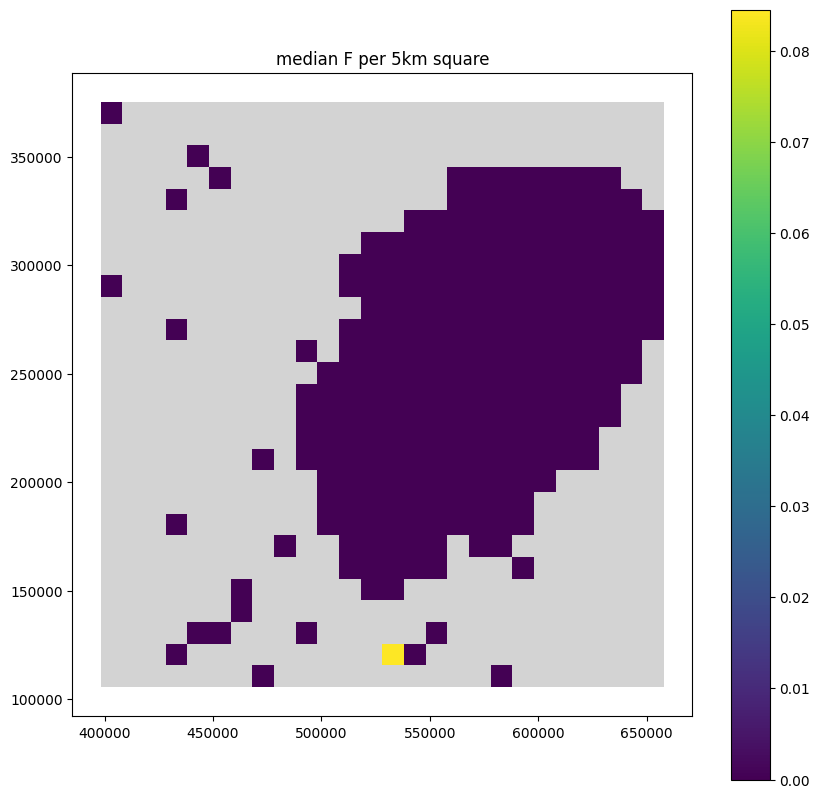

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))


grid.plot(
    column='median_f',
    ax=ax,
    cmap='viridis',
    legend=True,
    edgecolor=None,
    linewidth=0.2,
    missing_kwds={'color': 'lightgrey'}  # color cells with no points
)
plt.title("median F per 5km square")
plt.show()

In [105]:
# gdf.to_file("flex_option_3_101225.shp")

### Investigate difference by characteristics

In [46]:
def catFlex(score):
    if score == 0:
        return("0")
    elif score<1:
        return("0 to 1")
    elif score==1:
        return("1")
    elif score <2:
        return("1 to 2")
    elif score ==2:
        return("2")
    elif score <3:
        return("2 to 3")
    elif score ==3:
        return("3")
    elif score < 4:
        return("3 to 4")
    else:
        return("4")
df["flex_cat"]=df["flex_option_3_sum"].apply(catFlex)
df["trip_legs"] = df["m_sum"].apply(
    lambda x: len(x[0]) 
    if pd.notna(x[0]) and isinstance(x, (list, tuple)) and len(x[0]) > 0 
    else 0
)

In [47]:
df.groupby("flex_cat").count()

,Unnamed: 0,id,age,age_group,area_type,carAvail,car_avail,car_competition,disabled,ev,...,m,d,u,flex_option_3,flex_option_3_sum,flex_option_3_main,flex_option_3_unadjusted,flex_option_3_unadjusted_sum,flex_diff,trip_legs
flex_cat,,,,,,,,,,,,,,,,,,,,,
0,16160,16160,16160,16160,16160,16160,16160,16160,16160,16160,...,16160,16160,16160,16160,16160,16160,16160,16160,16160,16160
0 to 1,1501,1501,1501,1501,1501,1501,1501,1501,1501,1501,...,1501,1501,1501,1501,1501,1501,1501,1501,1501,1501
1,161,161,161,161,161,161,161,161,161,161,...,161,161,161,161,161,161,161,161,161,161
1 to 2,354,354,354,354,354,354,354,354,354,354,...,354,354,354,354,354,354,354,354,354,354
2,14,14,14,14,14,14,14,14,14,14,...,14,14,14,14,14,14,14,14,14,14
2 to 3,149,149,149,149,149,149,149,149,149,149,...,149,149,149,149,149,149,149,149,149,149
3 to 4,39,39,39,39,39,39,39,39,39,39,...,39,39,39,39,39,39,39,39,39,39
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,0,0,0,1,1,0,1


In [49]:
df=df[~df["flex_option_3_sum"].isna()]
df[df["flex_cat"]=="4"]

,Unnamed: 0,id,age,age_group,area_type,carAvail,car_avail,car_competition,disabled,ev,...,d,u,flex_option_3,flex_option_3_sum,flex_option_3_main,flex_option_3_unadjusted,flex_option_3_unadjusted_sum,flex_diff,flex_cat,trip_legs


In [50]:
def tripLength(m):
    try:
        if len(m[0]) > 4:
            return("4+")
        else:
            return(len(m[0]))
    except TypeError:
        return 0
def nUniqueModes(m):
    try:
        return(len(m))
    except TypeError:
        return 0
df["trip_length"] = df["m_sum"].apply(tripLength)
df["unique_modes"] = df["m_sum"].apply(nUniqueModes)

<Figure size 800x600 with 0 Axes>

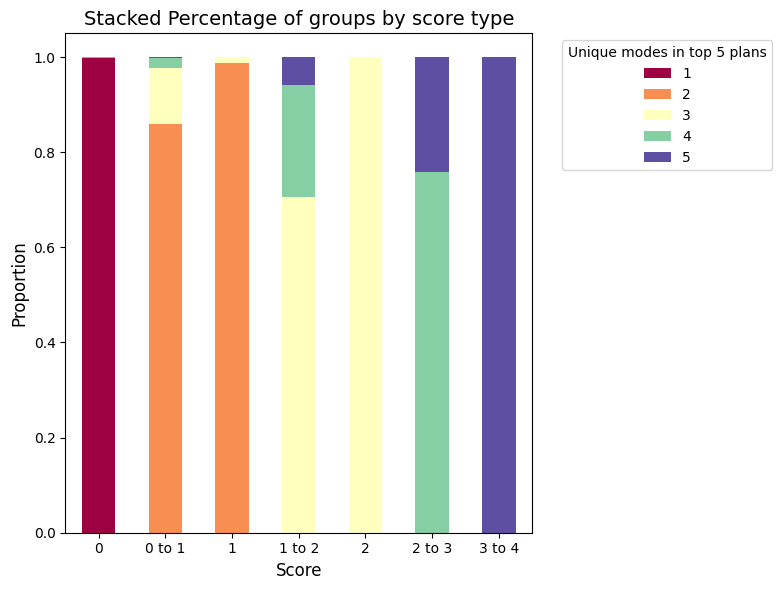

In [51]:
df_plot = pd.crosstab( df['flex_cat'], df['unique_modes'],normalize='index')
plt.figure(figsize=(8, 6))

df_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    colormap='Spectral'
)

# Formatting the plot
plt.title('Stacked Percentage of groups by score type', fontsize=14)
plt.ylabel('Proportion', fontsize=12)
plt.xlabel('Score', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Unique modes in top 5 plans', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [52]:
df[df["unique_modes"]>=4].head(15)

,Unnamed: 0,id,age,age_group,area_type,carAvail,car_avail,car_competition,disabled,ev,...,flex_option_3,flex_option_3_sum,flex_option_3_main,flex_option_3_unadjusted,flex_option_3_unadjusted_sum,flex_diff,flex_cat,trip_legs,trip_length,unique_modes
59,68555,161697,62.0,60 to 64,rural,True,yes,1.000000,no,True,...,2.019571,2.019571,0.000000,2.038142,2.038142,-0.018571,2 to 3,4,4,4
67,112129,200912,34.0,30 to 39,urban,False,never,0.000000,no,False,...,0.428153,0.428153,0.027692,0.447642,0.447642,-0.019488,0 to 1,6,4+,4
80,467959,81568,28.0,26 to 29,urban,True,yes,0.500000,no,False,...,2.811775,2.811775,0.000000,2.813941,2.813941,-0.002166,2 to 3,5,4+,4
120,369597,432634,54.0,50 to 59,urban,True,yes,1.000000,no,True,...,1.300836,1.300836,0.151445,1.546802,1.546802,-0.245967,1 to 2,8,4+,5
157,261592,33543,54.0,50 to 59,urban,True,yes,2.000000,no,True,...,2.185217,2.185217,0.000000,2.190636,2.190636,-0.005419,2 to 3,5,4+,4
158,140571,226510,44.0,40 to 49,urban,True,yes,1.000000,no,False,...,1.517748,1.517748,1.148501,1.517748,1.517748,0.000000,1 to 2,6,4+,4
267,188066,269257,44.0,40 to 49,urban,True,yes,1.333333,no,False,...,1.678936,1.678936,0.359210,1.710008,1.710008,-0.031072,1 to 2,8,4+,4
323,129116,216200,67.0,65 to 69,urban,True,yes,1.000000,no,True,...,3.104051,3.104051,0.000000,3.091558,3.091558,0.012493,3 to 4,6,4+,5
443,284623,356158,54.0,50 to 59,urban,True,yes,1.000000,no,True,...,2.870533,2.870533,0.000000,2.869154,2.869154,0.001379,2 to 3,6,4+,5
455,306461,375812,34.0,30 to 39,urban,True,yes,2.000000,no,True,...,2.525284,2.525284,0.000000,2.528875,2.528875,-0.003591,2 to 3,6,4+,4


In [75]:
df.iloc[522]["m_sum"]

[('walk', 'bus', 'walk', 'rail', 'walk', 'subway', 'walk'),
 ('walk', 'bus', 'walk', 'rail', 'walk', 'car'),
 ('car', 'walk', 'rail', 'walk', 'subway', 'walk', 'subway', 'walk'),
 ('car', 'walk', 'rail', 'walk', 'subway', 'walk')]

In [238]:
len(df[df["flex_option_3"].between(3, 4, inclusive="neither")])/len(df) * 100

0.2720496218510256

In [386]:
# df[df["flex_option_3"]>3].head(10)

In [127]:
df.loc[df['id'] == 346766, 'm'].item()

[('car', 'walk', 'subway', 'walk', 'rail', 'walk', 'car'),
 ('car', 'walk', 'walk', 'subway', 'walk', 'rail', 'walk', 'car'),
 ('car', 'walk', 'walk', 'subway', 'walk', 'rail', 'bike'),
 ('car', 'walk', 'subway', 'walk', 'rail', 'walk', 'taxi'),
 ('car', 'walk', 'subway', 'walk', 'rail', 'bike')]

### heatmaps

In [262]:
list(df.columns)

['Unnamed: 0',
 'id',
 'age',
 'age_group',
 'area_type',
 'carAvail',
 'car_avail',
 'car_competition',
 'disabled',
 'ev',
 'gender',
 'hasBike',
 'hasCar',
 'hasDisability',
 'hasLicence',
 'hcounty',
 'hhincome',
 'hholdnumchildren',
 'hhsize',
 'hid',
 'hid_old',
 'householdid',
 'hzone',
 'indincome',
 'individualid',
 'intermodalBike',
 'intermodalCar',
 'intermodalPassenger',
 'intermodalTaxi',
 'marital_status',
 'occupation',
 'region',
 'seasontickettype',
 'sex',
 'subpopulation',
 'surveyyear',
 'vehicles',
 'wfh',
 'workstatus',
 'selected plan activity_type_or_mode',
 'selected plan distance_travelled',
 'selected plan duration',
 'selected plan location',
 'selected plan routes',
 'selected plan number',
 'selected plan utility',
 'unselected plan (1) activity_type_or_mode',
 'unselected plan (1) distance_travelled',
 'unselected plan (1) duration',
 'unselected plan (1) location',
 'unselected plan (1) routes',
 'unselected plan (1) number',
 'unselected plan (1) utili

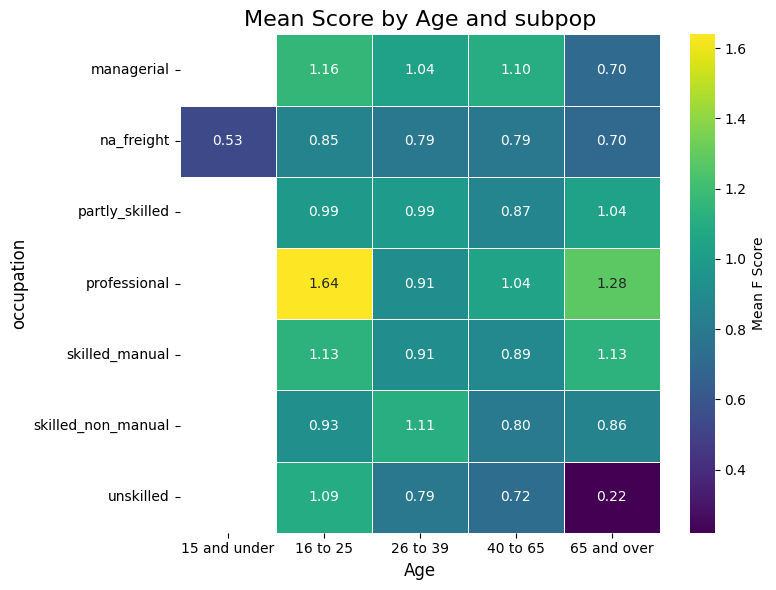

In [382]:
heatmap = (
    df3.groupby([ 'occupation', 'aggregate_age'])['flex_option_3']
    .mean() # Calculate the mean score
    .unstack() # Pivot 'gender' into columns
)
plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap,
    annot=True,          # Display the mean score value in each cell
    fmt=".2f",           # Format the annotation to 2 decimal places
    cmap="viridis",      # Choose a sequential color palette
    linewidths=.5,       # Add lines between cells for clarity
    cbar_kws={'label': 'Mean F Score'} # Label the color bar
)

plt.title('Mean Score by Age and subpop', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('occupation', fontsize=12)

plt.tight_layout()
plt.show()

### zero scorers

In [76]:
df0 = df[df["flex_option_3_sum"]==0]

In [77]:
df0["first_mode"]=df["m_sum"].apply(lambda x: x[0] if x else "None")

C:\Users\maria\AppData\Local\Temp\ipykernel_40956\1120163173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df0["first_mode"]=df["m_sum"].apply(lambda x: x[0] if x else "None")


In [78]:
def checkMode(mode, m):
    # print(type(mode))
    # print(type(m))
    try:
        if mode in m:
            return 1
        else:
            return 0
    except TypeError:
        return 0

In [79]:
df0["contains_car"]=df0.apply(lambda row: checkMode("car", row["first_mode"]), axis=1)
df0["contains_bus"]=df0.apply(lambda row: checkMode("bus", row["first_mode"]), axis=1)
df0["contains_bike"]=df0.apply(lambda row: checkMode("bike", row["first_mode"]), axis=1)
df0["contains_rail"]=df0.apply(lambda row: checkMode("rail", row["first_mode"]), axis=1)
df0["contains_subway"]=df0.apply(lambda row: checkMode("subway", row["first_mode"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3598485588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df0["contains_car"]=df0.apply(lambda row: checkMode("car", row["first_mode"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3598485588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df0["contains_bus"]=df0.apply(lambda row: checkMode("bus", row["first_mode"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_40956\3598485588.py:3: SettingWithCopyWarning: 
A value is trying to

In [80]:
print(len(df0[df0["contains_car"]==1])/len(df0))
print(len(df0[df0["contains_bus"]==1])/len(df0))
print(len(df0[df0["contains_rail"]==1])/len(df0))
print(len(df0[df0["contains_subway"]==1])/len(df0))
print(len(df0[df0["contains_bike"]==1])/len(df0))

0.5573019801980198
0.02530940594059406
0.00922029702970297
0.005136138613861386
0.02735148514851485


In [81]:
modes = df0.groupby("first_mode")["id"].count()
sorted_modes = modes.sort_values(ascending=False)
pd.set_option('display.max_rows', 1000)
print(sorted_modes)
print(len(df))

first_mode
(car,)                                                                      8982
(walk,)                                                                     3565
(car_passenger,)                                                            2584
(bike,)                                                                      430
(walk, bus, walk)                                                            170
(taxi,)                                                                      159
(walk, bus, walk, bus, walk)                                                  71
(walk, bus, walk, rail, walk, subway, walk)                                   12
(walk, bus, walk, rail, walk, bus, walk)                                      11
(walk, bus, walk, bus, walk, bus, walk)                                       11
(taxi, walk, rail, walk, bus, walk)                                           10
(taxi, walk, rail, walk)                                                       6
(walk, subway, wa

In [389]:
gdf0 = gpd.GeoDataFrame(df0, geometry='geometry', crs="EPSG:27700")  

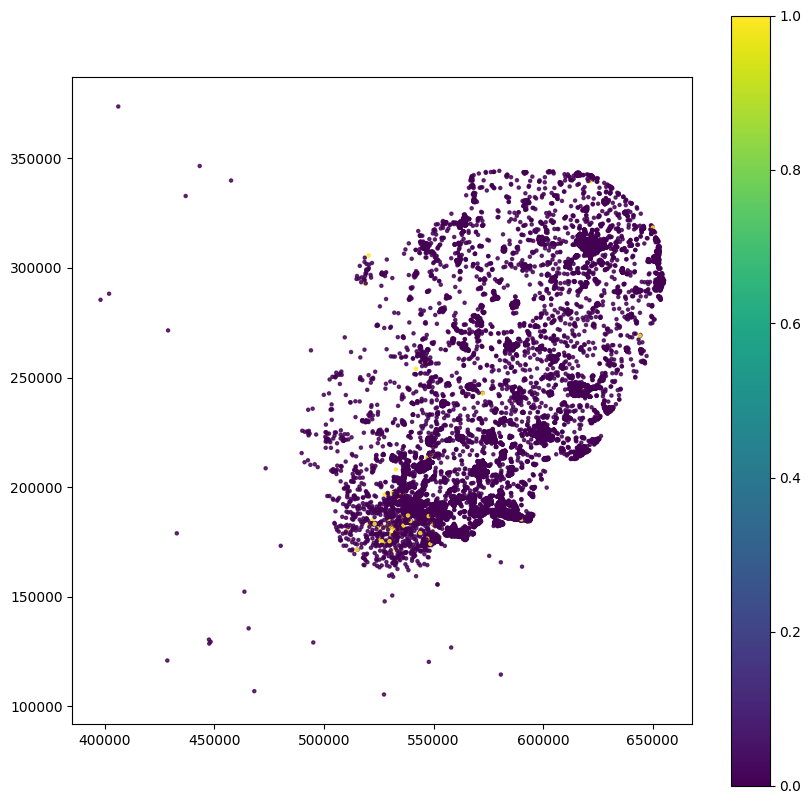

In [392]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf0.plot(
    ax=ax,
    column='contains_rail',
    cmap='viridis',
    legend=True,
    markersize=5,
    alpha=0.8,
    marker = 'o'
)

plt.show()

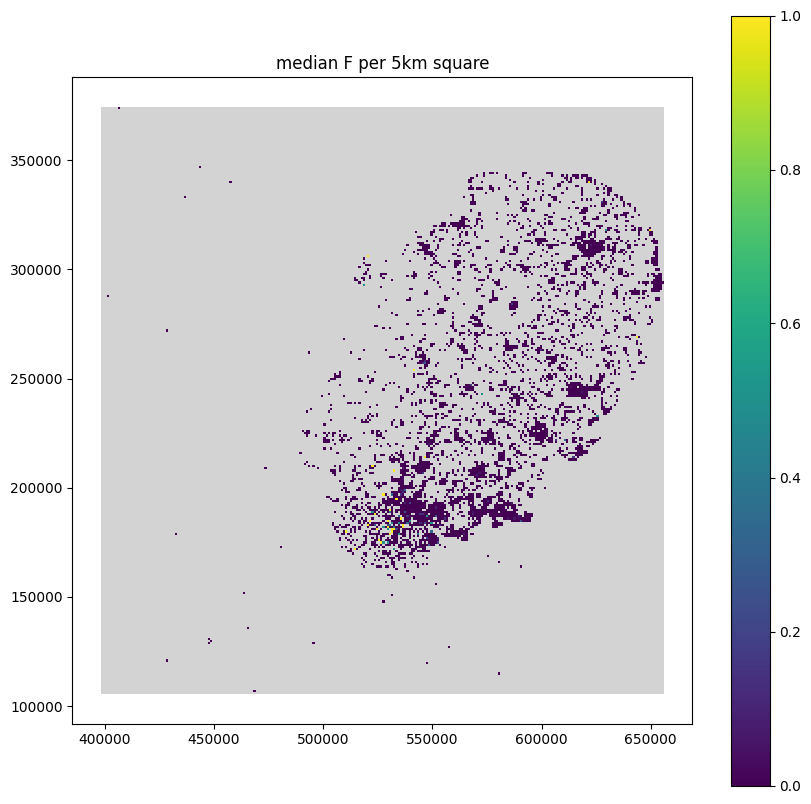

In [396]:
fig, ax = plt.subplots(figsize=(10,10))

grid_size = 1000  # adjust this to your desired grid cell size

# Get total bounds of your points: (xmin, ymin, xmax, ymax)
xmin, ymin, xmax, ymax = gdf0.total_bounds

# Create the grid cells
x_coords = np.arange(xmin, xmax + grid_size, grid_size)
y_coords = np.arange(ymin, ymax + grid_size, grid_size)

grid_cells = []
for x0 in x_coords[:-1]:
    for y0 in y_coords[:-1]:
        x1 = x0 + grid_size
        y1 = y0 + grid_size
        grid_cells.append(box(x0, y0, x1, y1))

grid = gpd.GeoDataFrame({'geometry': grid_cells})
grid.set_crs(gdf0.crs, inplace=True)
joined = gpd.sjoin(gdf0, grid, how='inner', predicate='within')
grid["mean_rail"] = joined.groupby('index_right')['contains_rail'].mean()
grid.plot(
    column='mean_rail',
    ax=ax,
    cmap='viridis',
    legend=True,
    edgecolor=None,
    linewidth=0.2,
    missing_kwds={'color': 'lightgrey'}  # color cells with no points
)
plt.title("median F per 5km square")
plt.show()

### non-zero scorers

In [393]:
df1 = df[df["flex_option_3"]>0]
df2 = df[df["flex_option_3"]>1]
print(len(df2)/len(df))

0.002611676369769846


In [389]:
df1["first_mode"]=df["m"].apply(lambda x: x[0] if x else "None")
df1["contains_car"]=df1.apply(lambda row: checkMode("car", row["first_mode"]), axis=1)
df1["contains_bus"]=df1.apply(lambda row: checkMode("bus", row["first_mode"]), axis=1)
df1["contains_bike"]=df1.apply(lambda row: checkMode("bike", row["first_mode"]), axis=1)
df1["contains_rail"]=df1.apply(lambda row: checkMode("rail", row["first_mode"]), axis=1)
df1["contains_subway"]=df1.apply(lambda row: checkMode("subway", row["first_mode"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_43092\3279729271.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["first_mode"]=df["m"].apply(lambda x: x[0] if x else "None")
C:\Users\maria\AppData\Local\Temp\ipykernel_43092\3279729271.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["contains_car"]=df1.apply(lambda row: checkMode("car", row["first_mode"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_43092\3279729271.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [392]:
modes1 = df1.groupby("first_mode")["id"].count()
sorted_modes1 = modes1.sort_values(ascending=False)
pd.set_option('display.max_rows', 1000)
print(sorted_modes1)
print(len(df1)/len(df))

first_mode
car              479
bus              366
walk             349
bike             120
rail             100
car_passenger     66
taxi              58
subway            45
Stuck              1
Name: id, dtype: int64
0.08618532020240492


## plotting the maths to visualise what's happening

In [409]:
f_at_1 = 0.1
print(f"for a flex score of {f_at_1} at 100% time difference, k should be: {-np.log((1/f_at_1)-1)}")

for a flex score of 0.1 at 100% time difference, k should be: -2.1972245773362196


In [ ]:
ktemp = 2.2
yieldtemp = 2/(1+np.exp(-ktemp))
difftemp = 0.1
print(f"for k={ktemp}, j should be: {1 / (np.arctanh(1-((yieldtemp-difftemp)/yieldtemp)))} for a {difftemp} difference at 100%")

for k=2.2, j should be: 17.986461578067786 for a 0.1 difference at 100%


In [424]:
ktemp = 2.2
gamma = (1+np.exp(ktemp))
btemp = 1
difftemp = 0.1
print(f"for alpha={ktemp}, beta should be: {(1/btemp)*np.log((1/ktemp)*np.log((2/difftemp)-1))} for a {difftemp} difference at b of {btemp}")

for alpha=2.2, beta should be: 0.29146093915781196 for a 0.1 difference at b of 1


In [82]:
x = np.linspace(-1.5, 1.5, 101)
y = (1/(1+np.exp(-1*2.2*x)))
pos025 = 1 - np.tanh(0.25/9)
pos05 = 1-np.tanh(0.5/9)
pos075 = 1-np.tanh(0.75/9)
neg025 = (1+np.tanh(-0.25/9))
neg05 = (1+np.tanh(-0.5/9))
neg075 = (1+np.tanh(-0.75/9))

In [83]:
y01 = (1/(1+np.exp(1*0.1*(x))))
y1 = (1/(1+np.exp(1*1*(x))))
y2 = (1/(1+np.exp(1*2*(x))))
y2point2 = (1/(1+np.exp(1*2.2*(x))))
y5 = (1/(1+np.exp(1*5*(x))))
y10 = (1/(1+np.exp(1*10*(x))))

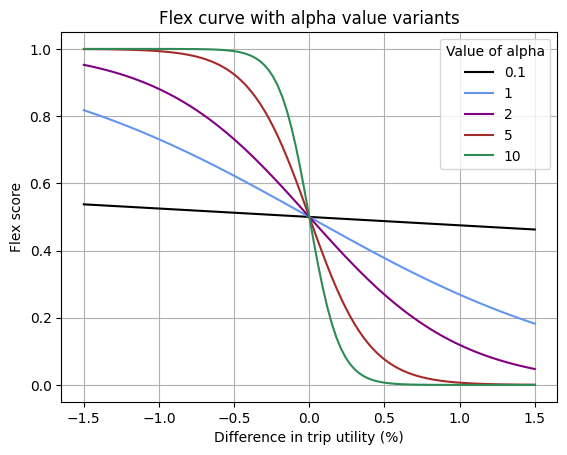

In [ ]:
plt.plot(x,y01,label = "0.1", color = "black")
plt.plot(x,y1,label = "1", color = "cornflowerblue")
plt.plot(x,y2,label = "2", color = "purple")
plt.plot(x,y5,label = "5", color = "brown")
plt.plot(x,y10,label = "10", color = "seagreen")
plt.grid()
plt.legend(title = "Value of alpha", loc = "upper right")#, bbox_to_anchor=(1.2, 0.5))
plt.xlabel("Difference in trip utility (%)")
plt.ylabel("Flex score")
plt.title("Flex curve with alpha value variants")
# plt.savefig("k_variant_curve_utility.jpg")

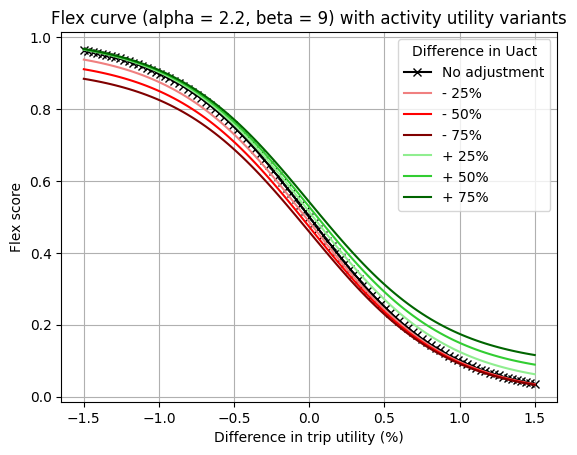

In [ ]:
plt.plot(x,y2point2, 'x-',label = "No adjustment", color = "black")
plt.grid()
plt.plot(x, y2point2*pos025, label = "- 25%", color = "lightcoral")
plt.plot(x, y2point2*pos05, label = "- 50%", color = "red")
plt.plot(x, y2point2*pos075, label = "- 75%", color = "maroon")
plt.plot(x, y2point2*neg025 - np.tanh(-0.25/9), label = "+ 25%", color = "lightgreen")
plt.plot(x, y2point2*neg05 - np.tanh(-0.5/9), label = "+ 50%", color = "limegreen")
plt.plot(x, y2point2*neg075 - np.tanh(-0.75/9), label = "+ 75%", color = "darkgreen")
plt.legend(title = "Difference in Uact", loc = "upper right")#, bbox_to_anchor=(1.43, 0.5))
plt.xlabel("Difference in trip utility (%)")
plt.ylabel("Flex score")
plt.title("Flex curve (alpha = 2.2, beta = 9) with activity utility variants")
# plt.savefig("alpha_variant_curve_utility.jpg")

In [86]:
y2point2p025 = (1/(1+np.exp((2.2*x)+0.25)))
y2point2p05 = (1/(1+np.exp((2.2*x)+0.5)))
y2point2p075 = (1/(1+np.exp((2.2*x)+0.75)))
y2point2n025 = (1/(1+np.exp((2.2*x)-0.25)))
y2point2n05 = (1/(1+np.exp((2.2*x)-0.5)))
y2point2n075 = (1/(1+np.exp((2.2*x)-0.75)))

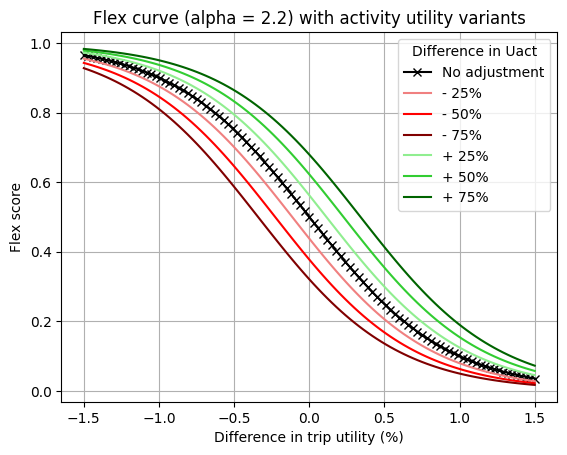

In [ ]:
plt.plot(x,y2point2, 'x-',label = "No adjustment", color = "black")
plt.grid()
plt.plot(x, y2point2p025, label = "- 25%", color = "lightcoral")
plt.plot(x, y2point2p05, label = "- 50%", color = "red")
plt.plot(x, y2point2p075, label = "- 75%", color = "maroon")
plt.plot(x, y2point2n025, label = "+ 25%", color = "lightgreen")
plt.plot(x, y2point2n05, label = "+ 50%", color = "limegreen")
plt.plot(x, y2point2n075, label = "+ 75%", color = "darkgreen")
plt.legend(title = "Difference in Uact", loc = "upper right")#, bbox_to_anchor=(1.43, 0.5))
plt.xlabel("Difference in trip utility (%)")
plt.ylabel("Flex score")
plt.title("Flex curve (alpha = 2.2) with activity utility variants")
# plt.savefig("y_variant_curve_utility.jpg")

In [403]:
base01 = (2/(1+np.exp((1*abs(x)))))
base02 = (2/(1+np.exp((2*abs(x)))))
base03 = (2/(1+np.exp((3*abs(x)))))
base04 = (2/(1+np.exp((4*abs(x)))))
base05 = (2/(1+np.exp((5*abs(x)))))

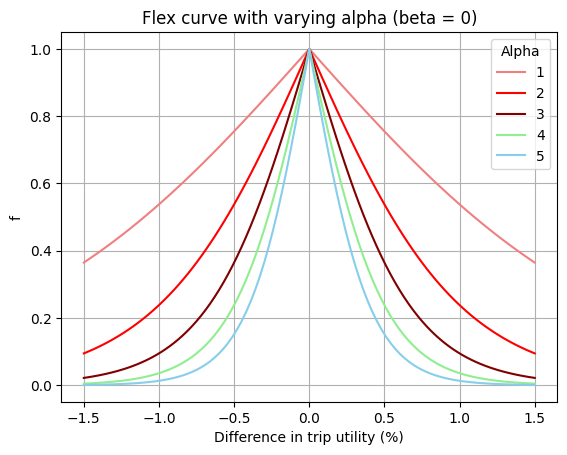

In [ ]:
plt.grid()
plt.plot(x, base01, label = "1", color = "lightcoral")
plt.plot(x, base02, label = "2", color = "red")
plt.plot(x, base03, label = "3", color = "maroon")
plt.plot(x, base04, label = "4", color = "lightgreen")
plt.plot(x, base05, label = "5", color = "skyblue")

plt.legend(title = "Alpha", loc = "upper right")#, bbox_to_anchor=(1.43, 0.5))
plt.xlabel("Difference in trip utility (%)")
plt.ylabel("f")
plt.title("Flex curve with varying alpha (beta = 0)")
# plt.savefig("option3_alpha_variant_curve_utility.jpg")

In [410]:
base = (2/(1+np.exp((2.2*abs(x)))))
same25 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.25*0.29)))))
same50 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.5*0.29)))))
same75 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.75*0.29)))))
opp25 = (2/(1+np.exp((2.2*abs(x)*np.exp(-0.25*0.29)))))
opp50 = (2/(1+np.exp((2.2*abs(x)*np.exp(-0.5*0.29)))))
opp75 = (2/(1+np.exp((2.2*abs(x)*np.exp(-0.75*0.29)))))

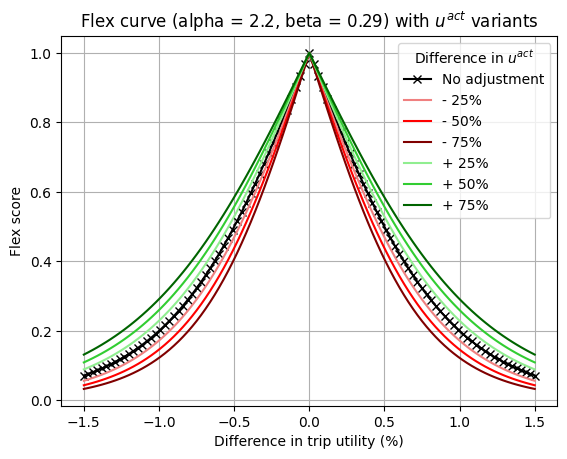

In [ ]:
plt.plot(x,base, 'x-',label = "No adjustment", color = "black")
plt.grid()
plt.plot(x, same25, label = "- 25%", color = "lightcoral")
plt.plot(x, same50, label = "- 50%", color = "red")
plt.plot(x, same75, label = "- 75%", color = "maroon")
plt.plot(x, opp25, label = "+ 25%", color = "lightgreen")
plt.plot(x, opp50, label = "+ 50%", color = "limegreen")
plt.plot(x, opp75, label = "+ 75%", color = "darkgreen")
plt.legend(title = "Difference in $u^{act}$", loc = "upper right")#, bbox_to_anchor=(1.43, 0.5))
plt.xlabel("Difference in trip utility (%)")
plt.ylabel("Flex score")
plt.title("Flex curve (alpha = 2.2, beta = 0.29) with $u^{act}$ variants")
# plt.savefig("option3_y_variant_curve_utility.jpg")

In [433]:
base = (2/(1+np.exp((2.2*abs(x)))))
beta01 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.1)))))
beta02 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.2)))))
beta03 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.3)))))
beta04 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.4)))))
beta05 = (2/(1+np.exp((2.2*abs(x)*np.exp(0.5)))))


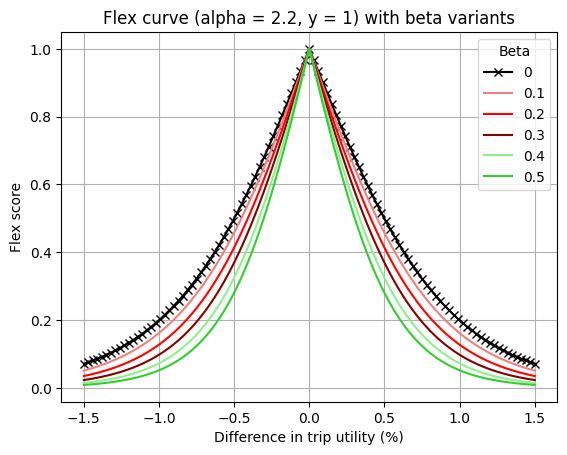

In [437]:
plt.plot(x,base, 'x-',label = "0", color = "black")
plt.grid()
plt.plot(x, beta01, label = "0.1", color = "lightcoral")
plt.plot(x, beta02, label = "0.2", color = "red")
plt.plot(x, beta03, label = "0.3", color = "maroon")
plt.plot(x, beta04, label = "0.4", color = "lightgreen")
plt.plot(x, beta05, label = "0.5", color = "limegreen")
plt.legend(title = "Beta", loc = "upper right")#, bbox_to_anchor=(1.43, 0.5))
plt.xlabel("Difference in trip utility (%)")
plt.ylabel("Flex score")
plt.title("Flex curve (alpha = 2.2, y = 1) with beta variants")
plt.savefig("option3_beta_variant_curve_utility.jpg")

Could also do a version that isnt mode agnostic, to calculate degree of car dependence?

### Now do the same, but for the longest trip only

### Now try the above but using utility instead of duration

### Now do the same but across the whole day
Consider:
* None-type trips (missed)